<a href="https://www.kaggle.com/code/akisavujel/diabetes-multivariate-linear-regression?scriptVersionId=300852516" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Import the necessary libraries
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/akisavujel/diabetes-for-multivariate-linear-regression/Diabetes.csv')
df.head(2)

,BMI,BP,Cholesterol,LDL,Target
0,26,99,165,75,524
1,39,65,285,92,717


In [3]:
# Seperate X and y
X = df[['BMI', 'BP', 'Cholesterol', 'LDL']]  
y = df['Target']

In [4]:
# Seperate for test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Fit train
reg = LinearRegression()
reg.fit(X_train, y_train)  

LinearRegression()

In [6]:
# Predict values
predict = reg.predict(X_test)
predict

array([705.39129263, 761.25918522, 720.20094621, 865.45330098,
       505.16813913, 764.64987995, 743.48772082, 583.10281085,
       819.5413881 , 928.13274205, 589.24372257, 670.51430514,
       744.59304568, 913.65219667, 649.81193439, 792.91195041,
       565.42048475, 733.96973962, 587.19201343, 534.66650148,
       798.73965973, 524.98973887, 772.74213134, 569.27166927,
       608.08741575, 597.49710354, 823.14874525, 712.83187191,
       795.8777001 , 774.25758947, 666.83659114, 820.83360095,
       631.10084116, 929.0456283 , 630.36252255, 664.15744308,
       833.99361221, 763.50213565, 560.45857963, 562.63530813])

In [7]:
#Prediction for first row
reg.predict(X.iloc[[0]])

array([544.88517833])

In [8]:
# Calculate mae, mse and r2
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
r2 = r2_score(y_test, predict)

print("Model Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Model Evaluation:
Mean Absolute Error (MAE): 22.114822380917957
Mean Squared Error (MSE): 744.0959904755624
R² Score: 0.9478149183108618


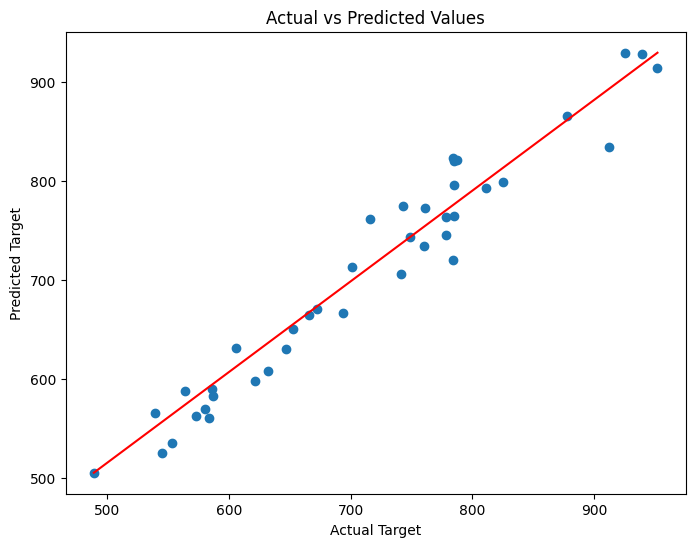

In [9]:
# Visualize the plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, predict)
plt.plot([y_test.min(), y_test.max()],
         [predict.min(), predict.max()],color = 'red')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('Actual vs Predicted Values')
plt.show()

In [10]:
predict_df = pd.DataFrame({'Actual value':y_test,'Predicted':predict, 'Difference': y_test - predict})
predict_df

,Actual value,Predicted,Difference
95,741,705.391293,35.608707
15,716,761.259185,-45.259185
30,784,720.200946,63.799054
158,878,865.453301,12.546699
128,489,505.168139,-16.168139
115,785,764.649880,20.350120
69,749,743.487721,5.512279
170,587,583.102811,3.897189
174,785,819.541388,-34.541388
45,939,928.132742,10.867258
